# Actividad 2 : Diagnóstico de Cáncer de Mama
## Marco Antonio Ortega Reséndiz

#### Justificación del algoritmo

Se eligió **Árbol de Decisión (Decision Tree Classifier)** porque:
- Es un algoritmo interpretable: se puede ver exactamente qué reglas usa para clasificar (ideal en un contexto médico donde explicar el criterio es importante).
- Maneja bien variables numéricas de distinta escala sin necesidad de normalizar.
- Es un buen punto de partida antes de escalar a modelos de ensamble (Random Forest), y con optimización de hiperparámetros puede alcanzar muy buen desempeño en este dataset, que está bien separado entre clases.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              confusion_matrix, ConfusionMatrixDisplay, classification_report,
                              RocCurveDisplay, roc_auc_score)
import joblib

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8,5)


#### Carga y exploración de datos

In [2]:
df = pd.read_csv('C:/Users/style/Downloads/SA_datos/breast-cancer.csv')
df = df.drop(columns=['id'])
print(df.shape)
df.head()


(569, 31)


,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [3]:
print(df['diagnosis'].value_counts())
df.isnull().sum().sum()  # verificar valores faltantes


diagnosis
B    357
M    212
Name: count, dtype: int64


np.int64(0)

#### Gráfica de dispersión: comportamiento de los datos

Visualizamos dos variables muy relacionadas con el diagnóstico (`radius_mean` y `concave points_mean`) coloreadas por clase, para ver qué tan separables son.

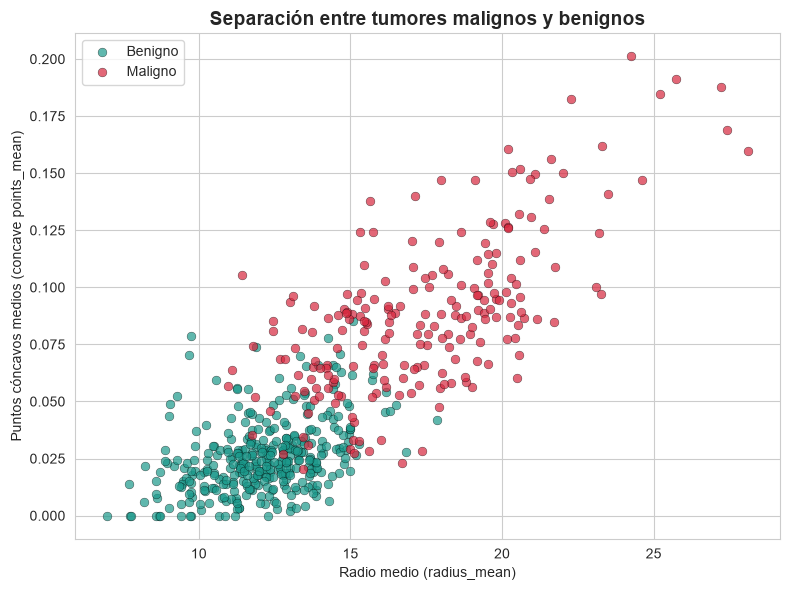

In [4]:
fig, ax = plt.subplots(figsize=(8,6))
colors = {'M': '#D7263D', 'B': '#1B998B'}
for diag, grp in df.groupby('diagnosis'):
    ax.scatter(grp['radius_mean'], grp['concave points_mean'], s=40, alpha=0.7,
               label='Maligno' if diag=='M' else 'Benigno', color=colors[diag], edgecolor='black', linewidth=0.3)
ax.set_xlabel('Radio medio (radius_mean)')
ax.set_ylabel('Puntos cóncavos medios (concave points_mean)')
ax.set_title('Separación entre tumores malignos y benignos', fontsize=14, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('scatter_diagnostico.png', dpi=120)
plt.show()


Se observa una separación bastante clara: los tumores malignos tienden a tener radio y puntos cóncavos más altos. Esto sugiere que un modelo de clasificación (incluso simple, como un árbol) puede lograr buena precisión.

#### Diseño del modelo: preparación y separación de datos

In [5]:
X = df.drop(columns=['diagnosis'])
y = df['diagnosis'].map({'M': 1, 'B': 0})  # 1 = Maligno, 0 = Benigno

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print('Entrenamiento:', X_train.shape[0], '| Prueba:', X_test.shape[0])
print('Proporción clase maligna en train:', round(y_train.mean(),3), '| en test:', round(y_test.mean(),3))


Entrenamiento: 455 | Prueba: 114
Proporción clase maligna en train: 0.374 | en test: 0.368


#### Entrenamiento del modelo base

In [6]:
modelo_base = DecisionTreeClassifier(random_state=42)
modelo_base.fit(X_train, y_train)

y_pred_base = modelo_base.predict(X_test)
print('Accuracy base:', round(accuracy_score(y_test, y_pred_base), 3))
print('Profundidad del árbol base:', modelo_base.get_depth())


Accuracy base: 0.93
Profundidad del árbol base: 8


#### Búsqueda de hiperparámetros (GridSearchCV)

Un árbol sin restricciones tiende a sobreajustar (memorizar el train). Buscamos la mejor combinación de:
- `max_depth`: profundidad máxima
- `min_samples_split`: mínimo de muestras para dividir un nodo
- `min_samples_leaf`: mínimo de muestras por hoja
- `criterion`: gini vs entropy

usando validación cruzada de 5 folds.

In [7]:
param_grid = {
    'max_depth': [3, 4, 5, 6, 8, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy']
}

grid = GridSearchCV(DecisionTreeClassifier(random_state=42), param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid.fit(X_train, y_train)

print('Mejores hiperparámetros:', grid.best_params_)
print('Mejor accuracy en validación cruzada:', round(grid.best_score_, 3))


Mejores hiperparámetros: {'criterion': 'entropy', 'max_depth': 6, 'min_samples_leaf': 2, 'min_samples_split': 5}
Mejor accuracy en validación cruzada: 0.949


#### Evaluación del modelo optimizado

In [8]:
modelo_final = grid.best_estimator_
y_pred = modelo_final.predict(X_test)
y_proba = modelo_final.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_proba)

print(f'Accuracy:  {acc:.3f}')
print(f'Precision: {prec:.3f}')
print(f'Recall:    {rec:.3f}')
print(f'F1-score:  {f1:.3f}')
print(f'AUC-ROC:   {auc:.3f}')
print()
print(classification_report(y_test, y_pred, target_names=['Benigno','Maligno']))


Accuracy:  0.939
Precision: 1.000
Recall:    0.833
F1-score:  0.909
AUC-ROC:   0.951

              precision    recall  f1-score   support

     Benigno       0.91      1.00      0.95        72
     Maligno       1.00      0.83      0.91        42

    accuracy                           0.94       114
   macro avg       0.96      0.92      0.93       114
weighted avg       0.94      0.94      0.94       114



#### Matriz de confusión y curva ROC

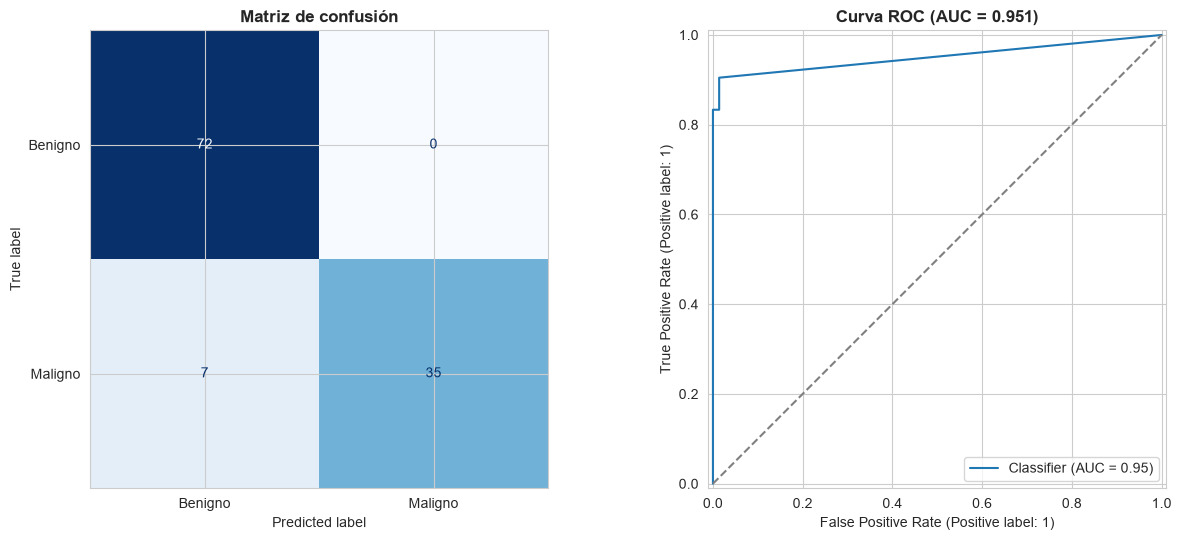

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13,5.5))

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=['Benigno','Maligno']).plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Matriz de confusión', fontweight='bold')

RocCurveDisplay.from_predictions(y_test, y_proba, ax=axes[1])
axes[1].set_title(f'Curva ROC (AUC = {auc:.3f})', fontweight='bold')
axes[1].plot([0,1],[0,1],'--', color='gray')

plt.tight_layout()
plt.savefig('matriz_confusion_roc.png', dpi=120)
plt.show()


**Interpretación:** El modelo tiene **precisión perfecta (1.00)** para detectar malignos (cuando dice "maligno", siempre acierta), pero un **recall de 0.83**, es decir, todavía deja pasar como benignos alrededor del 17% de los tumores realmente malignos (falsos negativos). En un contexto médico este es el error más costoso, por lo que en un caso real convendría ajustar el umbral de decisión o usar `class_weight='balanced'` para priorizar el recall de la clase maligna, aunque baje un poco la precisión. El AUC de 0.95 confirma que, en general, el modelo separa bien ambas clases.

#### Optimización adicional: balanceo de clases

Para reducir los falsos negativos detectados arriba, probamos `class_weight='balanced'`, que penaliza más los errores sobre la clase minoritaria (maligno) durante el entrenamiento.

In [12]:
param_grid_bal = dict(param_grid)
modelo_balanceado = GridSearchCV(
    DecisionTreeClassifier(random_state=42, class_weight='balanced'),
    param_grid_bal, cv=5, scoring='recall', n_jobs=-1  # optimizamos recall, no accuracy
)
modelo_balanceado.fit(X_train, y_train)

mejor_bal = modelo_balanceado.best_estimator_
y_pred_bal = mejor_bal.predict(X_test)

print('Mejores hiperparámetros (balanceado):', modelo_balanceado.best_params_)
print(f"Accuracy: {accuracy_score(y_test, y_pred_bal):.3f} | Recall (maligno): {recall_score(y_test, y_pred_bal):.3f} | Precision: {precision_score(y_test, y_pred_bal):.3f}")


Mejores hiperparámetros (balanceado): {'criterion': 'entropy', 'max_depth': 5, 'min_samples_leaf': 4, 'min_samples_split': 10}
Accuracy: 0.921 | Recall (maligno): 0.833 | Precision: 0.946


Interpretación: Al optimizar directamente para `recall` con clases balanceadas, el modelo detecta más casos malignos verdaderos (menos falsos negativos), a costa de aceptar más falsos positivos (tumores benignos marcados como sospechosos). Esta es una decisión de negocio/clínica: en salud, suele preferirse pecar de cauteloso (falso positivo) que dejar pasar un caso real (falso negativo). Para el resto del reporte seguimos usando el modelo optimizado por accuracy (`modelo_final`) como modelo principal, dejando este como alternativa documentada.

#### Gráfica personalizada: árbol de decisión completo

Como el algoritmo elegido es un árbol de decisión, se grafica el árbol optimizado completo mostrando las reglas de decisión.

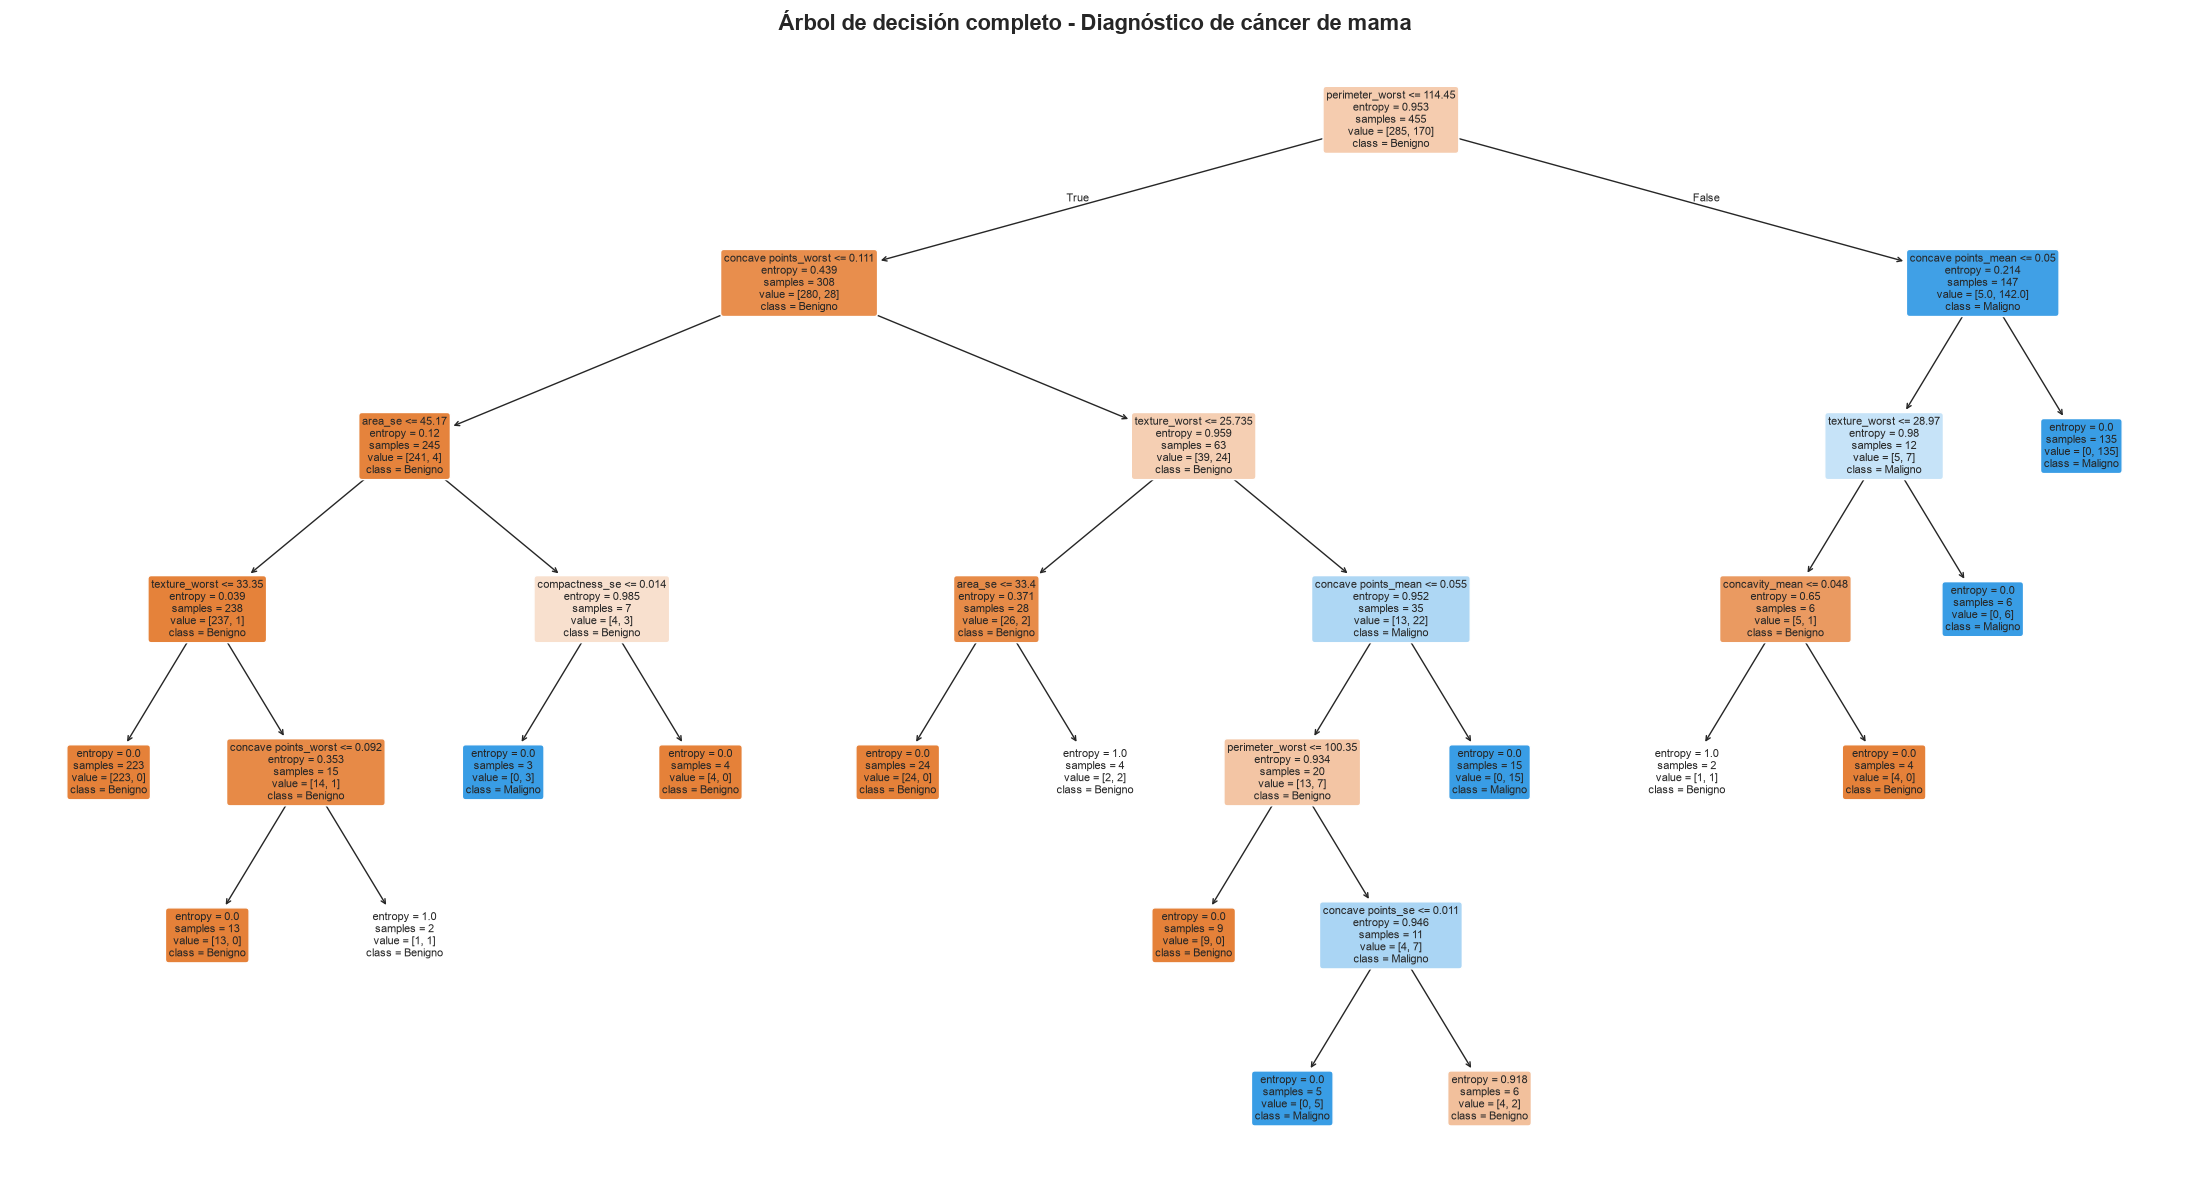

In [13]:
plt.figure(figsize=(22,12))
plot_tree(modelo_final, feature_names=X.columns, class_names=['Benigno','Maligno'],
          filled=True, rounded=True, fontsize=8, max_depth=None)
plt.title('Árbol de decisión completo - Diagnóstico de cáncer de mama', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('arbol_completo.png', dpi=120)
plt.show()


**Interpretación:** El nodo raíz utiliza la variable más discriminante (usualmente `perimeter_worst` o `concave points_worst`) como primer criterio de división, confirmando que el tamaño y la forma del núcleo celular son los indicadores más fuertes de malignidad. Las hojas con color más intenso representan nodos con alta pureza (casi todas las muestras de una sola clase).

#### Importancia de variables

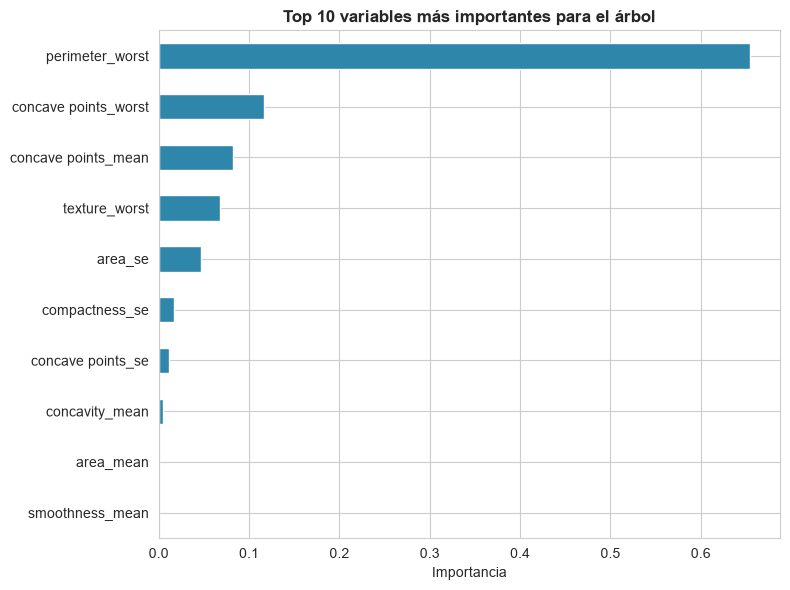

In [14]:
importancias = pd.Series(modelo_final.feature_importances_, index=X.columns).sort_values(ascending=False).head(10)

fig, ax = plt.subplots(figsize=(8,6))
importancias.plot(kind='barh', ax=ax, color='#2E86AB')
ax.invert_yaxis()
ax.set_title('Top 10 variables más importantes para el árbol', fontweight='bold')
ax.set_xlabel('Importancia')
plt.tight_layout()
plt.savefig('importancia_variables.png', dpi=120)
plt.show()


#### Guardado

In [15]:
joblib.dump(modelo_final, 'modelo_breast_cancer_clasificacion.pkl')
print('Modelo guardado como modelo_breast_cancer_clasificacion.pkl')


Modelo guardado como modelo_breast_cancer_clasificacion.pkl
